In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance

## Downloading data from Kaggle

In [4]:
# !pip install -q kaggle

# from google.colab import files
# files.upload()

# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

KeyboardInterrupt: 

In [5]:
!kaggle competitions download -c amex-default-prediction

 95%|█████████████████████████████████████▏ | 19.5G/20.5G [03:20<00:09, 104MB/s]

Connection error: OSError: [Errno 28] No space left on device
Retrying in 2.3 seconds... (attempt 1/5)
Retry 1/5: Resuming from 20940591104 bytes (1040936919 bytes left)...
 95%|███████████████████████████████████████████▊  | 19.5G/20.5G [00:00<?, ?B/s]

Connection error: OSError: [Errno 28] No space left on device
Retrying in 4.0 seconds... (attempt 2/5)
Retry 2/5: Resuming from 20940591104 bytes (1040936919 bytes left)...
 95%|███████████████████████████████████████████▊  | 19.5G/20.5G [00:00<?, ?B/s]

Connection error: OSError: [Errno 28] No space left on device
Retrying in 8.5 seconds... (attempt 3/5)
Retry 3/5: Resuming from 20940591104 bytes (1040936919 bytes left)...
 95%|███████████████████████████████████████████▊  | 19.5G/20.5G [00:00<?, ?B/s]

Connection error: OSError: [Errno 28] No space left on device
Retrying in 16.9 seconds... (attempt 4/5)
Retry 4/5: Resuming from 20940591104 bytes (10409

In [14]:
!unzip -o amex-default-prediction.zip train_data.csv train_labels.csv sample_submission.csv -d ./data

Archive:  amex-default-prediction.zip
  inflating: ./data/sample_submission.csv  
  inflating: ./data/train_data.csv   
  inflating: ./data/train_labels.csv  


In [10]:
!unzip -q amex-default-prediction.zip -d ./data

replace ./data/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace ./data/test_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
y
y


## Parsing into Pandas

In [5]:
parquet_path = "/kaggle/input/datasets/oksanayefimova/train-df/train.parquet"

In [4]:
pl.scan_csv("./data/train_data.csv").sink_parquet(parquet_path)
print("Train done")

Train done


In [1]:
def build_features_polars(parquet_path):

    cat_features = ["B_30", "B_38", "D_114", "D_116", "D_117", "D_120",
                    "D_126", "D_63", "D_64", "D_66", "D_68"]

    schema = pl.scan_parquet(parquet_path).collect_schema()
    all_cols = schema.names()

    numeric_dtypes = (pl.Float32, pl.Float64, pl.Int8, pl.Int16, pl.Int32,
                      pl.Int64, pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64)
    num_features = [c for c in all_cols
                    if c not in ['customer_ID', 'S_2'] + cat_features
                    and schema[c] in numeric_dtypes]

    print(f"  {len(num_features)} numeric features, {len(cat_features)} categorical")

    print("  building aggregation expressions...")
    num_agg_exprs = []
    for c in num_features:
        num_agg_exprs.extend([
            pl.col(c).mean().alias(f"{c}_mean"),
            pl.col(c).last().alias(f"{c}_last"),
        ])

    cat_agg_exprs = []
    for c in cat_features:
        cat_agg_exprs.extend([
            pl.col(c).last().alias(f"{c}_last"),
            pl.col(c).n_unique().alias(f"{c}_nunique"),
        ])

    count_expr = [pl.len().alias("n_statements")]

    print("  running numeric aggregation → sink (streaming)...")
    numeric_path = "test_features_numeric.parquet"
    (pl.scan_parquet(parquet_path)
       .group_by("customer_ID")
       .agg(num_agg_exprs + count_expr)
       .sink_parquet(numeric_path, engine="streaming")
    )

    print("  running categorical aggregation → sink...")
    cat_path = "test_features_cat.parquet"
    (pl.scan_parquet(parquet_path)
       .select(["customer_ID"] + cat_features)
       .group_by("customer_ID")
       .agg(cat_agg_exprs)
       .sink_parquet(cat_path, engine="streaming")
    )

    print("  joining results...")
    result = pl.read_parquet(numeric_path).join(
        pl.read_parquet(cat_path), on="customer_ID"
    )
    result = result.with_columns(pl.col(pl.Float64).cast(pl.Float32))

    print(f"  final shape: {result.shape}")
    return result.to_pandas()

In [6]:
train = build_features_polars(parquet_path)

  156 numeric features, 11 categorical
  building aggregation expressions...
  running numeric aggregation → sink (streaming)...
  running categorical aggregation → sink...
  joining results...
  final shape: (458913, 336)


In [7]:
train.head()

,customer_ID,P_2_mean,P_2_last,D_39_mean,D_39_last,B_1_mean,B_1_last,B_2_mean,B_2_last,R_1_mean,...,D_126_last,D_126_nunique,D_63_last,D_63_nunique,D_64_last,D_64_nunique,D_66_last,D_66_nunique,D_68_last,D_68_nunique
0,86ab35dc1a0d0f3b870624dad86f29a136e1a7386cdc18...,0.458161,0.335928,0.177114,0.182060,1.080158,1.241325,0.023951,0.025137,0.244982,...,1.0,1,CO,1,R,1,NaN,1,5.0,2
1,b81ce9955334688e0bac01d7f1ba46b27dc16240110753...,0.944809,0.982756,0.324422,0.538669,0.037047,0.047707,1.004143,1.008912,0.005060,...,1.0,1,CR,2,R,2,NaN,1,6.0,2
2,0246a9eefe65d23331ca7e144c58b9d65ee730bf03cbaf...,0.481547,0.479867,0.017528,0.039136,0.026675,0.057439,0.541305,0.483941,0.006657,...,0.0,1,CO,1,None,1,NaN,1,NaN,1
3,693aec160fcd75484f226f61174bb5ec5e7760adeabc7f...,0.581875,0.592345,0.106913,0.037793,0.297653,0.298061,0.062001,0.056205,0.005092,...,1.0,1,CO,1,O,1,1.0,1,6.0,1
4,7875aea9dc5e8289177a1c5376e73e346c538c02ea8313...,0.325029,0.332253,0.011763,0.009228,0.208331,0.023149,0.707935,1.008171,0.005509,...,1.0,2,CR,1,O,2,NaN,1,6.0,2


In [8]:
labels_path = "/kaggle/input/competitions/amex-default-prediction/train_labels.csv"
labels_df = pd.read_csv(labels_path)
labels_df.head()

,customer_ID,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0


In [9]:
train_df = pd.merge(labels_df, train, on='customer_ID', how='inner')

In [10]:
train_df.head()

,customer_ID,target,P_2_mean,P_2_last,D_39_mean,D_39_last,B_1_mean,B_1_last,B_2_mean,B_2_last,...,D_126_last,D_126_nunique,D_63_last,D_63_nunique,D_64_last,D_64_nunique,D_66_last,D_66_nunique,D_68_last,D_68_nunique
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0,0.933824,0.934745,0.010704,0.009119,0.012007,0.009382,1.005086,1.007647,...,1.0,1,CR,1,O,1,NaN,1,6.0,1
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0,0.899820,0.880519,0.215205,0.178126,0.025654,0.034684,0.991083,1.004028,...,1.0,1,CO,1,O,1,NaN,1,6.0,1
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0,0.878454,0.880875,0.004181,0.009704,0.004386,0.004284,0.815677,0.812649,...,1.0,1,CO,1,R,1,NaN,1,6.0,1
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0,0.598969,0.621776,0.048862,0.001083,0.059876,0.012564,0.955265,1.006183,...,1.0,1,CO,1,O,1,NaN,1,3.0,3
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0,0.891679,0.871900,0.004644,0.005573,0.005941,0.007679,0.814543,0.815746,...,1.0,1,CO,1,O,1,1.0,1,6.0,1


## Hist Gradient Boosting Algorithm

In [11]:
X = train_df.drop(columns=["customer_ID", "target"])
y = train_df["target"]
#X_test = test_df.drop(columns=["customer_ID"])

In [12]:
import gc
del train_df
gc.collect()

0

In [13]:
text_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

if text_cols:
  X = X.drop(columns=text_cols)

X = X.select_dtypes(include=[np.number])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))
cv_scores = []
train_scores = []
models_list = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    model = HistGradientBoostingClassifier(max_iter=150, 
                                           learning_rate=0.1, 
                                           l2_regularization=0.5,
                                           random_state=336, 
                                           verbose=0
                                          )

    model.fit(X_train, y_train)
    models_list.append(model)

    train_preds = model.predict_proba(X_train)[:, 1]
    train_auc = roc_auc_score(y_train, train_preds)
    train_scores.append(train_auc)
    
    val_preds = model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds
    
    fold_auc = roc_auc_score(y_val, val_preds)
    cv_scores.append(fold_auc)
    
    print(f"Fold {fold + 1} | Train AUC: {train_auc:.4f} | Val (OOF) AUC:"f" {fold_auc:.4f}")

    if fold == 4:
        last_model = model
        last_X_val = X_val
        last_y_val = y_val

    del X_train, y_train, X_val, y_val
    gc.collect()

overall_auc = roc_auc_score(y, oof_preds)
print(f"\nTotal OOF ROC-AUC: {overall_auc:.4f}")

Fold 1 | Train AUC: 0.9659 | Val (OOF) AUC: 0.9608
Fold 2 | Train AUC: 0.9662 | Val (OOF) AUC: 0.9595
Fold 3 | Train AUC: 0.9662 | Val (OOF) AUC: 0.9600
Fold 4 | Train AUC: 0.9662 | Val (OOF) AUC: 0.9594
Fold 5 | Train AUC: 0.9660 | Val (OOF) AUC: 0.9602

Total OOF ROC-AUC: 0.9600


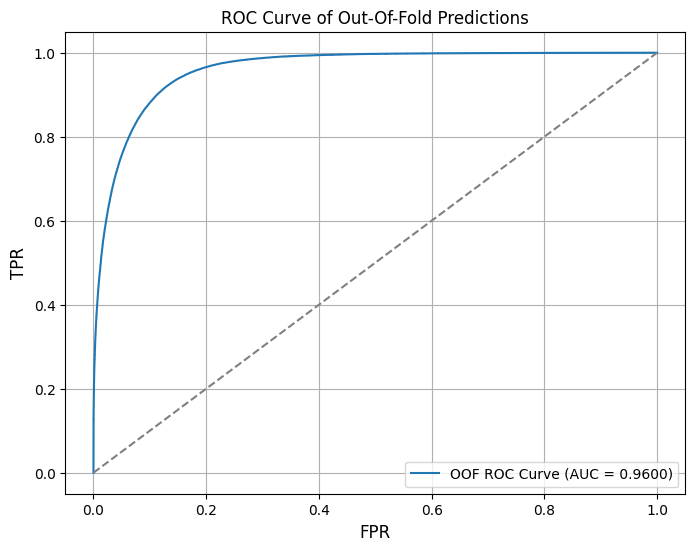

In [14]:
fpr, tpr, thresholds = roc_curve(y, oof_preds)

plt.figure(figsize=(8, 6))
plt.plot(fpr,tpr, label=f"OOF ROC Curve (AUC = {overall_auc:.4f})")
plt.plot([0, 1], [0, 1], color="grey", linestyle="--")
plt.xlabel("FPR", fontsize=12)
plt.ylabel("TPR", fontsize=12)
plt.title("ROC Curve of Out-Of-Fold Predictions")
plt.legend()
plt.grid()
plt.show()

In [19]:
result = permutation_importance(
    last_model,
    last_X_val,
    last_y_val,
    scoring="roc_auc",
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std}
                                    ).sort_values(by="importance_mean", ascending=False)

print("\nTOP 10 features:")
print(feature_importance_df.head(10))


TOP 10 features:
      feature  importance_mean  importance_std
1    P_2_last         0.017834        0.000248
5    B_1_last         0.002436        0.000139
23   B_4_last         0.001841        0.000023
3   D_39_last         0.001685        0.000061
16  D_42_mean         0.001254        0.000058
15   B_3_last         0.000875        0.000036
31  D_46_last         0.000619        0.000013
27   B_5_last         0.000517        0.000024
10   S_3_mean         0.000490        0.000063
13  D_41_last         0.000371        0.000047


## ML Baseline Submision

In [3]:
pl.scan_csv("/kaggle/input/competitions/amex-default-prediction/test_data.csv").sink_parquet('test_parquet.parquet')

In [3]:
test_df = build_features_polars("/kaggle/working/test_parquet.parquet")

  164 numeric features, 11 categorical
  building aggregation expressions...
  running numeric aggregation → sink (streaming)...
  running categorical aggregation → sink...
  joining results...
  final shape: (924621, 352)


In [15]:
X_test = test_df.drop(columns=["customer_ID"], errors="ignore")
X_test = X_test[X.columns]
X_test = X_test.select_dtypes(include=[np.number])
final_preds = np.zeros(len(X_test))

for model in models_list:
  preds = model.predict_proba(X_test)[:, 1]
  final_preds += preds / len(models_list)

submission = pd.DataFrame(
    {"customer_ID": test_df["customer_ID"], "prediction": final_preds}
)

submission.to_csv("submission.csv", index=False)

In [16]:
!kaggle competitions submit -c amex-default-prediction -f submission.csv -m "HistGradientBoosting baseline submission"

100%|██████████████████████████████████████| 75.2M/75.2M [00:01<00:00, 65.4MB/s]
Successfully submitted to American Express - Default Prediction